In [1]:
import numpy as np
import cv2
from pyproj import Transformer
from my_vbr_utils.vbr_dataset import vbrInterpolatedDataset, load_calibration, get_paths_from_scene
from my_vbr_utils.utilities import load_scene_correspondences
import matplotlib.pyplot as plt

# --- Config and Dataset Loading ---
# Set these variables to configure your scene and utility path
scene_name = 'campus_train0'
dataset_root_dir = "/datasets/vbr_slam"
calib_path = get_paths_from_scene(dataset_root_dir, scene_name)[-1]
calib = load_calibration(calib_path)

dataset = vbrInterpolatedDataset(dataset_root_dir,scene_name)
### LOAD MAST3R MODEL AND INFERENCE UTILITIES
from mast3r.model import AsymmetricMASt3R
#load model
device = 'cuda:1'

CHECKPOINT = "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
# CHECKPOINT="/home/bjangley/VPR/mast3r-v2/checkpoints_v12/ciampino_train0_ciampino_train1_lr5/checkpoint-10.pth"
# CHECKPOINT="/home/bjangley/VPR/mast3r-v2/checkpoints/ciampino_train0_ciampino_train1/checkpoint-5.pth"
# CHECKPOINT="/home/bjangley/VPR/mast3r-old/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth"
model = AsymmetricMASt3R.from_pretrained(CHECKPOINT).to(device)
# print(model)

def plot_pointclouds_top_view(pointclouds, labels=None, colors=None, s=10, alpha=0.5, title=None, ax=None):
    """
    Plot multiple point clouds in top-down (X-Z) view.
    pointclouds: list of (N,3) arrays
    labels: list of strings
    colors: list of colors
    """
    if not isinstance(pointclouds, list):
        pointclouds = [pointclouds]
    if labels is None:
        labels = [f"Cloud {i}" for i in range(len(pointclouds))]
    if colors is None:
        colors = ['blue', 'orange', 'green', 'red', 'purple']
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    for i, pts in enumerate(pointclouds):
        if pts is not None and pts.size > 0:
            ax.scatter(pts[:, 0], pts[:, 2], c=colors[i % len(colors)], s=s, marker='o', alpha=alpha, label=labels[i])
    ax.set_xlabel('X (Right)')
    ax.set_ylabel('Z (Forward)')
    ax.set_title(title if title else 'Top-View of Point Clouds')
    ax.axis('equal')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

Loaded vbrInterpolatedDataset from scene:  campus_train0
Images loaded from:  /datasets/vbr_slam/campus/campus_train0_kitti/camera_left/data
Ground Truth Poses:  /datasets/vbr_slam/campus/campus_train0/campus_train0_gt.txt


/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/model.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Fundamental matrix: 1719 matches, 1639 inliers, 80 outliers
Image Shaoe:  700 1388
Mast3r image shape:  256 512


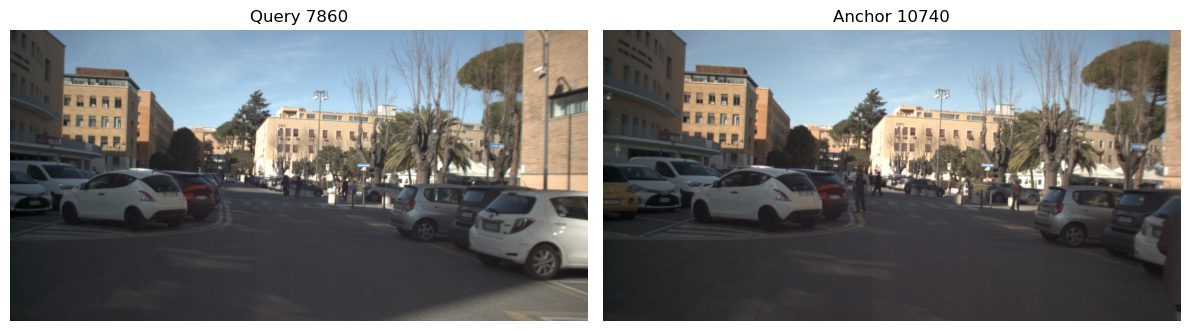

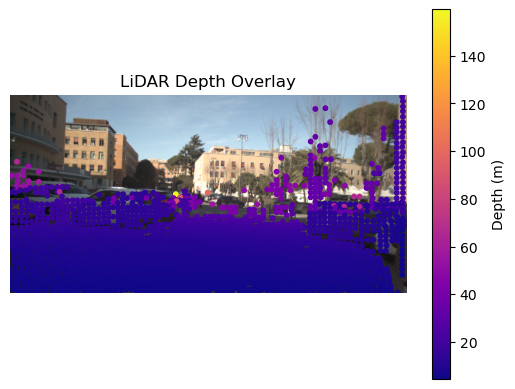

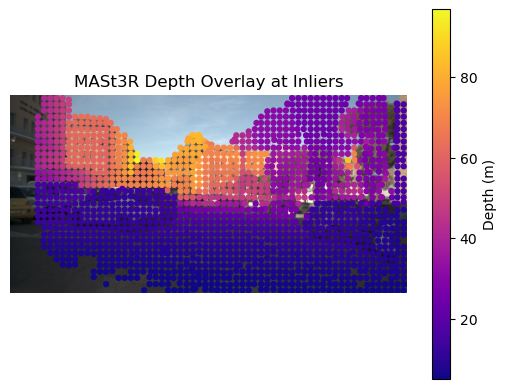

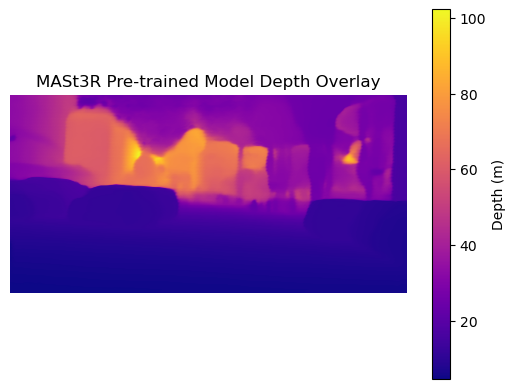

Recovered 384 matches with depth
Number of inlier matches: 384


In [2]:
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from scipy.spatial.transform import Rotation as Rscipy
from my_utils.mast3r_utils import get_master_output, get_mast3r_image_shape,scale_intrinsics,overlap,plot_depth_overlay_on_image,plot_lidar_mast3r_matches
from my_utils.my_vbr_dataset import generate_depth_and_scene_maps
from my_utils.mast3r_utils import recompute_intrinsics
from my_utils.plotting import show_image_pair
# --- Load anchor-query pair ---
pairs_df = pd.read_csv('/home/bjangley/VPR/mast3r-v2/pairs_mining/campus_train0/campus_matches_inliers_fm_top10_anchors_per_query.csv')
row = pairs_df.iloc[130]
anchor_idx, query_idx = int(row['anchor_idx']), int(row['query_idx'])
# anchor_idx, query_idx = 11200, 11201
anchor = dataset[anchor_idx]
query  = dataset[query_idx]
gt_pose = query['pose']

# --- Run MASt3R model and extract matches ---
output = get_master_output(
    model, device,
    anchor['image'],
    query['image'],
    visualize=False,
    verbose=False
)
matches_im0 = output[0]
matches_im1 = output[1]
pts3d_im0   = output[2]


# --- find number of inliers from the matches ---
if len(matches_im0) >= 8:
    F, mask_f = cv2.findFundamentalMat(matches_im0, matches_im1, cv2.FM_RANSAC, 1, 0.99)
    num_inliers_f = int(mask_f.sum()) if mask_f is not None else 0
    inlier_mask = mask_f.ravel().astype(bool)
    inlier_im0 = matches_im0[inlier_mask]
    inlier_im1 = matches_im1[inlier_mask]
else:
    num_inliers_f = 0
    inlier_im0 = np.empty((0, 2))
    inlier_im1 = np.empty((0, 2))
print(f"Fundamental matrix: {len(matches_im0)} matches, {num_inliers_f} inliers, {len(matches_im0) - num_inliers_f} outliers")

T_cam_lidar = calib['cam_l']['T_cam_lidar']
K = calib['cam_l']['K']
# --- LiDAR projection and image resizing ---
img = cv2.imread(anchor['image'])
H, W = img.shape[:2]
print("Image Shaoe: ", H, W)
mast3r_w, mast3r_h = get_mast3r_image_shape(W, H)
print("Mast3r image shape: ", mast3r_h, mast3r_w)
# K_new = scale_intrinsics(K, W, H, mast3r_w, mast3r_h)
K_new = recompute_intrinsics(K,(W,H),size=512)
depth_map, scene_map = generate_depth_and_scene_maps(anchor['lidar_points'], K_new, T_cam_lidar, (mast3r_h, mast3r_w))

# --- Load and show anchor/query images ---
anchor_img = Image.open(anchor['image'])
query_img = Image.open(query['image'])
show_image_pair(anchor_img, query_img, anchor_idx, query_idx)

# --- LiDAR depth overlay ---
img_orig = plt.imread(anchor['image'])
img_resized = cv2.resize(img_orig, (mast3r_w, mast3r_h))
img_resized = img_resized.astype(np.float32) / 255.0 if img_resized.dtype == np.uint8 else img_resized
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)
plot_depth_overlay_on_image(img_resized, scene_map, pixel_uv, point_size=10, alpha=1.0, title="LiDAR Depth Overlay")

# # --- MASt3R 3D points overlay ---
# if len(matches_im0) > 0:
#     plot_depth_overlay_on_image(
#         img_resized,
#         pts3d_im0,
#         matches_im0,
#         point_size=12,
#         cmap='plasma',
#         alpha=1.0,
#         title="MASt3R Depth Overlay on all Matches"
#     )
if num_inliers_f > 0:
    plot_depth_overlay_on_image(
        img_resized,
        pts3d_im0,
        inlier_im0,
        point_size=12,
        cmap='plasma',
        alpha=1.0,
        title="MASt3R Depth Overlay at Inliers"
    )


H, W, _ = pts3d_im0.shape 
u_grid, v_grid = np.meshgrid(np.arange(W), np.arange(H)) #mast3r image shape
all_uv = np.stack([u_grid.ravel(), v_grid.ravel()], axis=-1)  # shape (H*W, 2)
if num_inliers_f > 0:
    plot_depth_overlay_on_image(
        img_resized,
        pts3d_im0,
        all_uv,
        point_size=12,
        cmap='plasma',
        alpha=1.0,
        title="MASt3R Pre-trained Model Depth Overlay"
    )

# --- Overlap between inlier keypoints and LiDAR depth map ---

matched_uv, matched_lidar_uv, matched_indices = overlap(inlier_im0, depth_map, max_pixel_dist=2)
inlier_im0 = inlier_im0[matched_indices]
inlier_im1 = inlier_im1[matched_indices]
print(f"Recovered {len(matched_uv)} matches with depth")
print(f"Number of inlier matches: {len(inlier_im0)}")


# # --- Plot top-down view of point clouds ---
# plot_pointclouds_top_view(
#     [lidar_pts, master_pts, master_pts_scaled],
#     labels=['LiDAR', 'MASt3R', 'Scaled MASt3R'],
#     colors=['blue', 'orange', 'green'],
#     title='Top-Down View: Matched LiDAR and MASt3R Points'
# )

In [3]:
print(K_new)

[[466.7815996    0.         239.46567833]
 [  0.         464.46110758 127.78155621]
 [  0.           0.           1.        ]]


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.
Num points: 32768
X range: -132.31152 to 159.47266
Y range: -29.418167 to 45.250294
Z range: -2.997845 to 24.681427
Distance range: 0.0 to 159.77377
Percentiles (distance): [10.82293558 16.26245546 24.95344315 30.96541529 56.23440434]
[Open3D INFO] Window window_0 created.
[Open3D INFO] EGL headless mode enabled.
[Open3D INFO] ICE servers: ["stun:stun.l.google.com:19302", "turn:user:password@34.69.27.100:3478", "turn:user:password@34.69.27.100:3478?transport=tcp"]
FEngine (64 bits) created at 0x7fd09c009990 (threading is enabled)
[Open3D INFO] Set WEBRTC_STUN_SERVER environment variable add a customized WebRTC STUN server.
[Open3D INFO] WebRTC Jupyter handshake mode enabled.
EGL(1.5)
OpenGL(4.1)


WebVisualizer(window_uid='window_0')

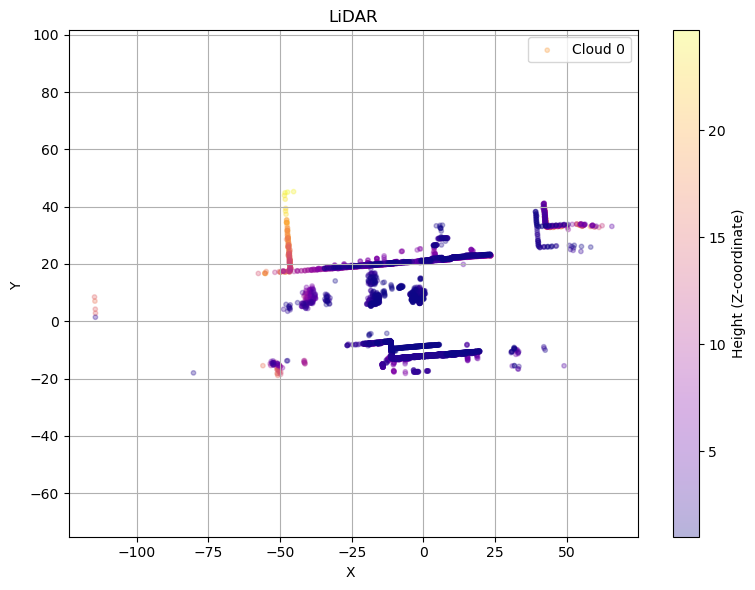

32768
[[ 0.00561709 -0.9999834   0.00132127  0.23482969]
 [-0.0012881  -0.00132847 -0.99999831 -0.66564557]
 [ 0.9999835   0.0056154  -0.00129556 -0.07291627]
 [ 0.          0.          0.          1.        ]]
(32768, 3)
[Open3D INFO] Window window_1 created.


WebVisualizer(window_uid='window_1')

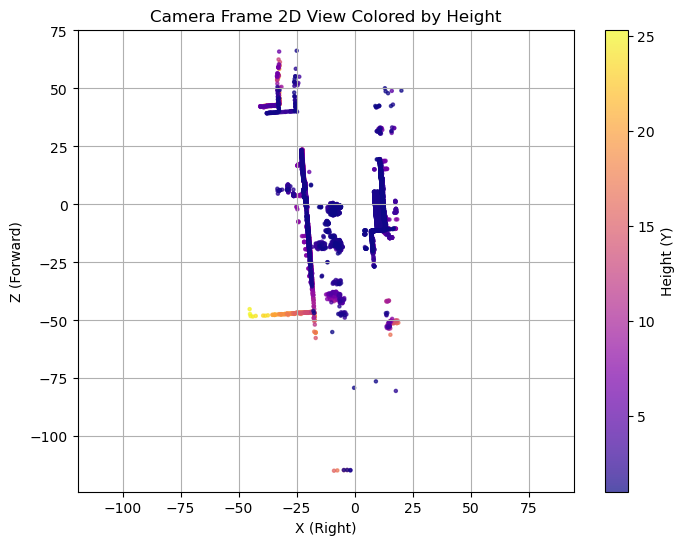

Z range (camera frame): -132.41589163075267 159.4530178681377
Points in front of camera: 12744


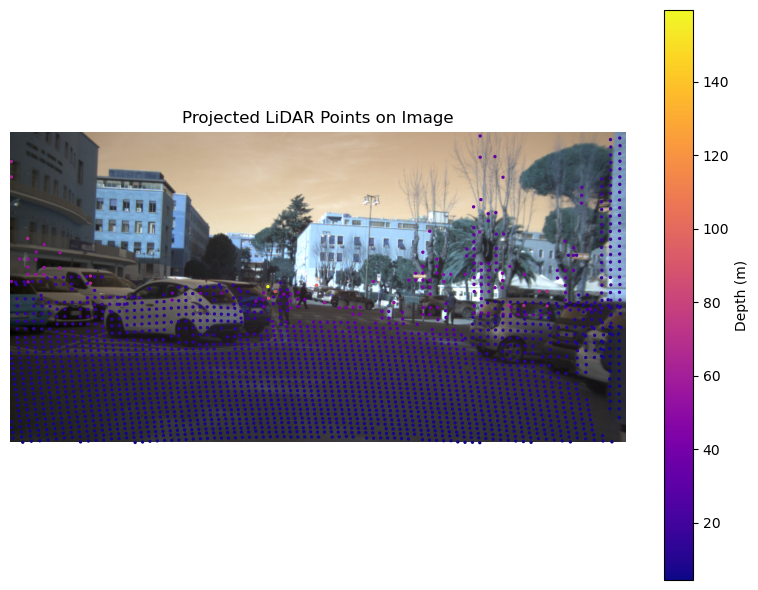

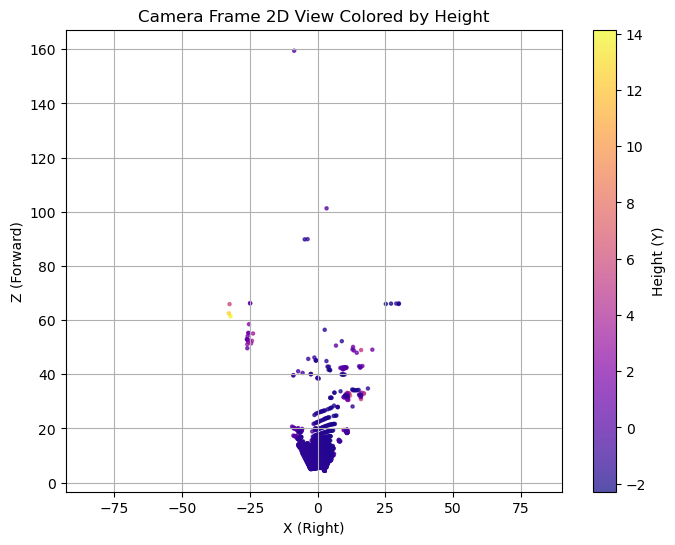

[Open3D INFO] Window window_2 created.


WebVisualizer(window_uid='window_2')

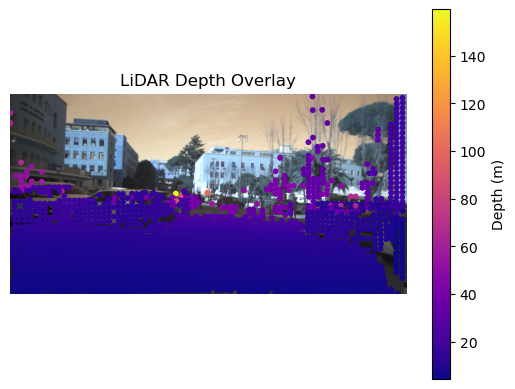

In [4]:
anchor_lidar = anchor['lidar_points']

import open3d as o3d
import numpy as np
from open3d.visualization import webrtc_server
from open3d.web_visualizer import draw as wv_draw



def create_axes_lines(length=1.0):
    points = [
        [0, 0, 0],
        [length, 0, 0],
        [0, length, 0],
        [0, 0, length],
    ]
    lines = [
        [0, 1],  # X axis
        [0, 2],  # Y axis
        [0, 3],  # Z axis
    ]
    colors = [
        [1, 0, 0],  # Red for X
        [0, 1, 0],  # Green for Y
        [0, 0, 1],  # Blue for Z
    ]
    line_set = o3d.geometry.LineSet(
        points=o3d.utility.Vector3dVector(points),
        lines=o3d.utility.Vector2iVector(lines)
    )
    line_set.colors = o3d.utility.Vector3dVector(colors)
    return line_set


def visualize_point_cloud(points):
    """Visualizes a point cloud using Open3D."""
    if points is None or len(points) == 0:
        print("No points to visualize.")
        return

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    # (Optional) Estimate normals for better visualization
    # pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    # pcd.orient_normals_towards_camera_location(camera_location=[0, 0, 0])  # Adjust camera location if needed
    lines = create_axes_lines(length=1.0)
    wv_draw([pcd, lines])
    # wv_draw(pcd) 

# Example usage:
anchor_lidar = anchor['lidar_points']  # Assuming this is where you load the LiDAR points
dists = np.linalg.norm(anchor_lidar, axis=1)

print("Num points:", len(anchor_lidar))
print("X range:", anchor_lidar[:, 0].min(), "to", anchor_lidar[:, 0].max())
print("Y range:", anchor_lidar[:, 1].min(), "to", anchor_lidar[:, 1].max())
print("Z range:", anchor_lidar[:, 2].min(), "to", anchor_lidar[:, 2].max())
print("Distance range:", dists.min(), "to", dists.max())
print("Percentiles (distance):", np.percentile(dists, [50, 75, 90, 95, 99]))

visualize_point_cloud(anchor_lidar)

anchor_lidar=anchor['lidar_points']
import matplotlib.pyplot as plt
import numpy as np

def plot_pointclouds_top_view_colored_by_height(pointclouds, labels=None, colors=None, s=10, alpha=0.3, title=None, ax=None, cmap='plasma', height_threshold=None):
    """
    Plot multiple point clouds in top-down (X-Z) view, colored by height (Y-coordinate),
    with an option to filter points based on a height threshold.
    pointclouds: list of (N,3) arrays
    labels: list of strings
    colors: list of colors (ignored when coloring by height)
    s: marker size
    alpha: transparency
    title: plot title
    ax: matplotlib axes object
    cmap: colormap to use (e.g., 'viridis', 'plasma', 'jet')
    height_threshold: Minimum height (Y-coordinate) for points to be plotted. If None, no filtering is applied.
    """
    if not isinstance(pointclouds, list):
        pointclouds = [pointclouds]
    if labels is None:
        labels = [f"Cloud {i}" for i in range(len(pointclouds))]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    for i, pts in enumerate(pointclouds):
        if pts is not None and pts.size > 0:
            # Apply height threshold filtering
            if height_threshold is not None:
                valid_heights = pts[:, 2] > height_threshold
                pts = pts[valid_heights]

            # Use height (Y-coordinate) as the color value
            heights = pts[:, 2]
            if len(pts) > 0:  # Check if there are any points left after filtering
                scatter = ax.scatter(pts[:, 0], pts[:, 1], c=heights, s=s, marker='o', alpha=alpha, cmap=cmap, label=labels[i])

    ax.set_xlabel('X ')
    ax.set_ylabel('Y ')
    ax.set_title(title if title else 'Top-View of Point Clouds Colored by Height')
    ax.axis('equal')
    ax.legend()
    ax.grid(True)

    # Add a colorbar to show the height mapping
    if 'scatter' in locals():  # Only add colorbar if there are points to plot
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Height (Z-coordinate)')

    plt.tight_layout()
    plt.show()


plot_pointclouds_top_view_colored_by_height(anchor_lidar, title="LiDAR",height_threshold=1)
print(len(anchor_lidar))

print(T_cam_lidar)
pts_hom = np.hstack([anchor_lidar, np.ones((anchor_lidar.shape[0], 1))])
cam_pts = (T_cam_lidar @ pts_hom.T).T
print(cam_pts[:,:3].shape)
visualize_point_cloud(cam_pts[:,:3])


def plot_camera_frame_2d(points, height_threshold=None, title="Camera Frame Point Cloud"):
    """
    Plot 2D scatter of camera frame points, points colored by height (Z axis here).
    Args:
      points: Nx3 numpy array in camera frame coordinates.
      height_threshold: If set, only points with height (Z) > threshold shown.
      title: Plot title string.
    """
    if height_threshold is not None:
        points = points[points[:, 1] < -height_threshold]

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(points[:, 0], points[:, 2], c=-points[:, 1], cmap='plasma', s=5, alpha=0.7)
    plt.xlabel('X (Right)')
    plt.ylabel('Z (Forward)')
    plt.title(title)
    plt.colorbar(scatter, label='Height (Y)')
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Usage example:
plot_camera_frame_2d(cam_pts, height_threshold=1, title="Camera Frame 2D View Colored by Height")


import numpy as np

import numpy as np
import cv2

def generate_depth_and_scene_maps2(pts_lidar, K, T_cam_lidar, img_shape, dist_coeffs=None, img=None):
    """
    Projects LiDAR points into the image frame and constructs depth and scene maps.

    Args:
    - pts_lidar: (N, 3) LiDAR points in LiDAR frame
    - K: (3, 3) camera intrinsic matrix
    - T_cam_lidar: (4, 4) transformation from LiDAR to camera frame
    - img_shape: (H, W) tuple of image shape
    - dist_coeffs: (4,) or (5,) distortion coefficients, or None

    Returns:
    - depth_map: (H, W) float32, depth at each pixel (0 = unobserved)
    - scene_map: (H, W, 3) float32, 3D camera-space point per pixel (nan = unobserved)
    - cam_pts: (N, 3) filtered 3D camera points
    """
    H, W = img_shape
    # 1. Transform lidar → camera
    pts_hom = np.hstack([pts_lidar, np.ones((pts_lidar.shape[0], 1))])  # (N, 4)
    cam_pts = (T_cam_lidar @ pts_hom.T).T[:, :3]  # (N, 3)
    print("Z range (camera frame):", np.min(cam_pts[:, 2]), np.max(cam_pts[:, 2]))
    print("Points in front of camera:", np.sum(cam_pts[:, 2] > 0))
    # 2. Filter out points behind the camera
    valid = cam_pts[:, 2] > 0
    cam_pts = cam_pts[valid]

    # 3. Project to image plane (with distortion if provided)
    if dist_coeffs is not None:
        rvec = np.zeros((3, 1), dtype=np.float64)
        tvec = np.zeros((3, 1), dtype=np.float64)
        uv, _ = cv2.projectPoints(cam_pts, rvec, tvec, K, dist_coeffs)
        uv = uv.squeeze()  # (N, 2)
        u, v = uv[:, 0], uv[:, 1]
    else:
        uv = (K @ cam_pts.T).T  # (N, 3)
        uv = uv[:, :2] / uv[:, 2:]  # Normalize by Z
        u, v = uv[:, 0], uv[:, 1]
    # 4. Filter points inside image bounds
    in_bounds = (u >= 0) & (u < W) & (v >= 0) & (v < H)
    u, v = u[in_bounds], v[in_bounds]
    cam_pts = cam_pts[in_bounds]
    if img is not None:
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.scatter(u, v, c=cam_pts[:, 2], cmap='plasma', s=2)
        plt.colorbar(label='Depth (m)')
        plt.title("Projected LiDAR Points on Image")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    # 5. Initialize maps
    depth_map = np.zeros((H, W), dtype=np.float32)
    scene_map = np.full((H, W, 3), np.nan, dtype=np.float32)

    # 6. Rasterize using Z-buffer: store closest point per pixel
    u_int = u.astype(int)
    v_int = v.astype(int)

    for i in range(len(u_int)):
        x, y = u_int[i], v_int[i]
        z = cam_pts[i, 2]
        if depth_map[y, x] == 0 or z < depth_map[y, x]:
            depth_map[y, x] = z
            scene_map[y, x] = cam_pts[i]

    return depth_map, scene_map, cam_pts



H, W = img.shape[:2]
results1 = generate_depth_and_scene_maps2(anchor_lidar, K, T_cam_lidar, (H, W), dist_coeffs=calib['cam_l']['dist_coeffs'], img=img)
plot_camera_frame_2d(results1[-1], height_threshold=None, title="Camera Frame 2D View Colored by Height")
visualize_point_cloud(results1[-1])
v, u = np.where(np.isfinite(results1[0]))
pixel_uv = np.stack((u, v), axis=-1)
plot_depth_overlay_on_image(img, results1[1], pixel_uv, point_size=10, alpha=1.0, title="LiDAR Depth Overlay")


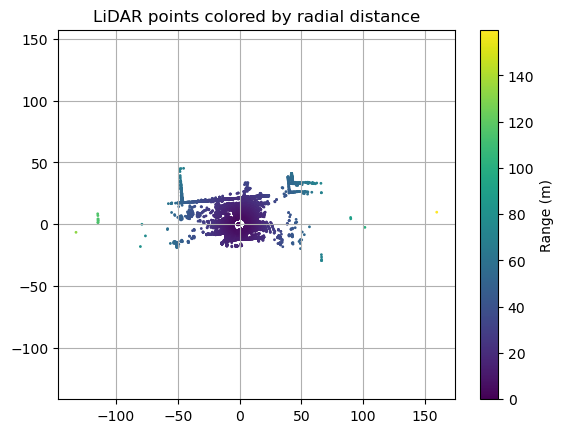

[[ 0.00561709 -0.9999834   0.00132127  0.23482969]
 [-0.0012881  -0.00132847 -0.99999831 -0.66564557]
 [ 0.9999835   0.0056154  -0.00129556 -0.07291627]
 [ 0.          0.          0.          1.        ]]


In [5]:
distances = np.linalg.norm(anchor_lidar, axis=1)
plt.scatter(anchor_lidar[:, 0], anchor_lidar[:, 1], c=distances, cmap='viridis', s=1)
plt.colorbar(label="Range (m)")
plt.axis('equal')
plt.grid()
plt.title("LiDAR points colored by radial distance")
plt.show()

print(T_cam_lidar)

In [6]:
import numpy as np

fx = K[0, 0]   # focal length in pixels

fov_x_rad = 2 * np.arctan(W / (2 * fx))
fov_x_deg = np.degrees(fov_x_rad)
print(f"Horizontal FOV: {fov_x_deg:.2f} degrees")


Horizontal FOV: 57.48 degrees


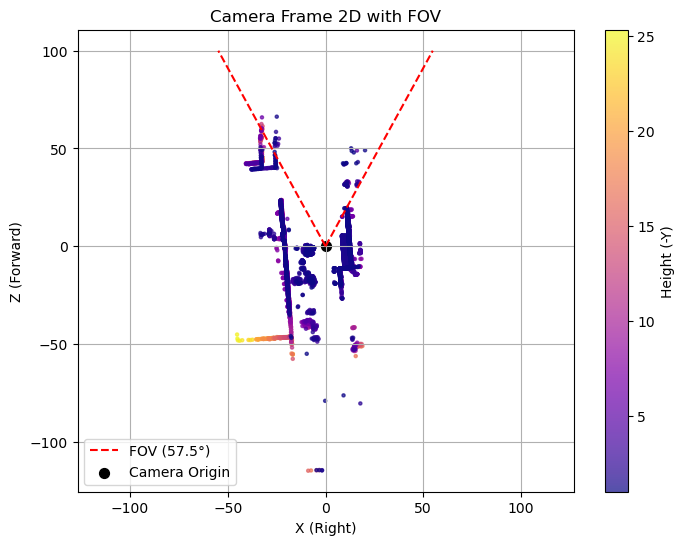

In [7]:
def plot_camera_frame_with_fov(points, fx, fy, img_width, img_height,
                                height_threshold=None, fov_depth=10,
                                title="Camera Frame 2D with FOV"):
    """
    Plots the camera frame point cloud and overlays the FOV cone.
    """
    # Filter by height
    if height_threshold is not None:
        points = points[points[:, 1] < -height_threshold]

    # Plot point cloud
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(points[:, 0], points[:, 2], c=-points[:, 1],
                          cmap='plasma', s=5, alpha=0.7)

    # Compute horizontal FOV in radians
    hfov = 2 * np.arctan(img_width / (2 * fx))

    # Draw FOV cone
    half_angle = hfov / 2
    z = fov_depth
    x_left = -z * np.tan(half_angle)
    x_right = z * np.tan(half_angle)

    plt.plot([0, x_left], [0, z], 'r--', label=f"FOV ({np.degrees(hfov):.1f}°)")
    plt.plot([0, x_right], [0, z], 'r--')
    plt.scatter([0], [0], c='black', s=50, label="Camera Origin")

    # Labels and layout
    plt.xlabel("X (Right)")
    plt.ylabel("Z (Forward)")
    plt.title(title)
    plt.colorbar(scatter, label='Height (-Y)')
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage:
plot_camera_frame_with_fov(
    cam_pts,
    fx=K[0,0],
    fy=K[1,1],
    img_width=W,
    img_height=H,
    height_threshold=1,
    fov_depth=100  # Distance to draw FOV cone
)

In [8]:
print(calib['cam_l']['dist_coeffs'])

[-0.15442154  0.22415793  0.00028612 -0.0011553 ]


In [9]:
import numpy as np
import cv2
from typing import Tuple


def compute_fov_from_intrinsics(K: np.ndarray, image_shape: Tuple[int, int]) -> Tuple[float, float]:
    """
    Compute horizontal and vertical FOV from intrinsics and image shape.

    Args:
        K: (3, 3) camera intrinsic matrix
        image_shape: (H, W) of the image

    Returns:
        (fov_x_deg, fov_y_deg) in degrees
    """
    fx = K[0, 0]
    fy = K[1, 1]
    H, W = image_shape
    fov_x = 2 * np.arctan(W / (2 * fx))
    fov_y = 2 * np.arctan(H / (2 * fy))
    return np.rad2deg(fov_x), np.rad2deg(fov_y)


def get_points_in_camera_fov(
    fov: Tuple[float, float],
    points_cam: np.ndarray,
    horizontal_only: bool = False
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Filter points inside camera field of view (horizontal/vertical angles).

    Args:
        fov: (horizontal, vertical) FOV in degrees
        points_cam: (N, 3) 3D points in camera frame
        horizontal_only: whether to use only horizontal FOV

    Returns:
        - Filtered points (N', 3)
        - Boolean mask of inliers (N,)
    """
    h_fov, v_fov = fov
    x, y, z = points_cam[:, 0], points_cam[:, 1], points_cam[:, 2]
    h_angle = np.rad2deg(np.arctan2(x, z))
    mask = (-h_fov / 2 < h_angle) & (h_angle < h_fov / 2)

    if not horizontal_only:
        v_angle = np.rad2deg(np.arctan2(y, z))
        mask &= (-v_fov / 2 < v_angle) & (v_angle < v_fov / 2)

    return points_cam[mask], mask


def project_3d_to_2d_opencv(
    points_cam: np.ndarray,
    K: np.ndarray,
    dist: np.ndarray = None
) -> np.ndarray:
    """
    Project 3D camera-frame points to 2D using OpenCV pinhole model.

    Args:
        points_cam: (N, 3) 3D points in camera frame
        K: (3, 3) camera intrinsic matrix
        dist: (4,) or (5,) distortion coefficients

    Returns:
        (N, 2) pixel coordinates in image
    """
    rvec = np.zeros((3, 1), dtype=np.float64)
    tvec = np.zeros((3, 1), dtype=np.float64)
    uv, _ = cv2.projectPoints(points_cam, rvec, tvec, K, dist)
    return uv.squeeze()


def project_lidar_to_image(
    lidar_points: np.ndarray,
    T_cam_lidar: np.ndarray,
    K: np.ndarray,
    dist: np.ndarray,
    image_shape: Tuple[int, int],
    fov: Tuple[float, float] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Project LiDAR points to image and return (x, y, depth) + valid mask.

    Args:
        lidar_points: (N, 3) LiDAR points in LiDAR frame
        T_cam_lidar: (4, 4) transform from LiDAR → camera
        K: (3, 3) camera intrinsics
        dist: (4,) distortion coefficients
        image_shape: (H, W)
        fov: (Hfov, Vfov) in degrees — optional, for angular filtering

    Returns:
        - xyd: (M, 3) pixel_x, pixel_y, depth
        - mask: (N,) bool mask of visible LiDAR points
    """
    H, W = image_shape
    N = lidar_points.shape[0]

    # Transform to camera frame
    pts_hom = np.hstack([lidar_points, np.ones((N, 1))])
    cam_pts = (T_cam_lidar @ pts_hom.T).T[:, :3]

    # Positive depth
    in_front = cam_pts[:, 2] > 0
    cam_pts = cam_pts[in_front]

    if cam_pts.shape[0] == 0:
        return np.empty((0, 3)), np.zeros(N, dtype=bool)

    if fov is not None:
        cam_pts, fov_mask = get_points_in_camera_fov(fov, cam_pts)
    else:
        fov_mask = np.ones(cam_pts.shape[0], dtype=bool)

    if cam_pts.shape[0] == 0:
        return np.empty((0, 3)), np.zeros(N, dtype=bool)

    # Project
    uv = project_3d_to_2d_opencv(cam_pts, K, dist)
    u, v = uv[:, 0], uv[:, 1]
    in_img = (u >= 0) & (u < W) & (v >= 0) & (v < H)

    # Final outputs
    uv = uv[in_img]
    depths = cam_pts[in_img, 2]
    xyd = np.concatenate([uv, depths[:, None]], axis=1)

    final_mask = np.zeros(N, dtype=bool)
    temp_mask = in_front.copy()
    temp_mask[temp_mask] = fov_mask  # update True locations only
    final_mask[temp_mask] = in_img

    return xyd, final_mask

fov = compute_fov_from_intrinsics(K, (H, W))
# Project
xyd, mask = project_lidar_to_image(
    lidar_points=anchor_lidar,
    T_cam_lidar=T_cam_lidar,
    K=K,
    dist=calib['cam_l']['dist_coeffs'],
    image_shape=(H, W),
    fov=fov
)

[Open3D INFO] Sending init frames to window_2.


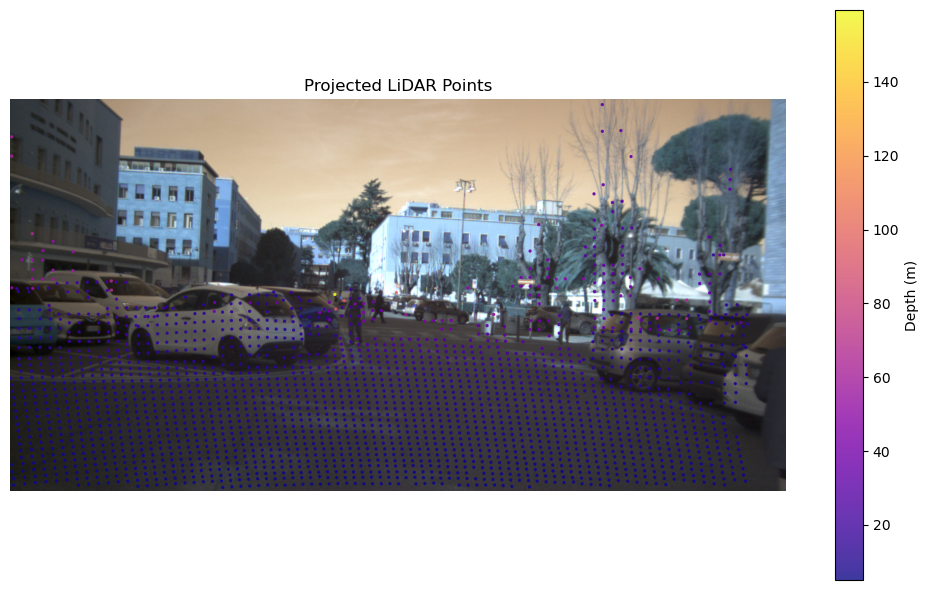

In [10]:
import matplotlib.pyplot as plt

def overlay_projected_points(
    img: np.ndarray,
    xyd: np.ndarray,
    s: int = 2,
    cmap: str = "plasma",
    alpha: float = 0.8,
    title: str = "Projected LiDAR Points"
):
    """
    Overlay 2D projected LiDAR points on the image.

    Args:
        img: (H, W, 3) image array (RGB or BGR)
        xyd: (N, 3) array of [u, v, depth]
        s: marker size
        cmap: color map for depth
        alpha: transparency
        title: plot title
    """
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.scatter(xyd[:, 0], xyd[:, 1], c=xyd[:, 2], cmap=cmap, s=s, alpha=alpha)
    plt.colorbar(label='Depth (m)')
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Overlay on image
overlay_projected_points(img, xyd)